# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from IHP PDK

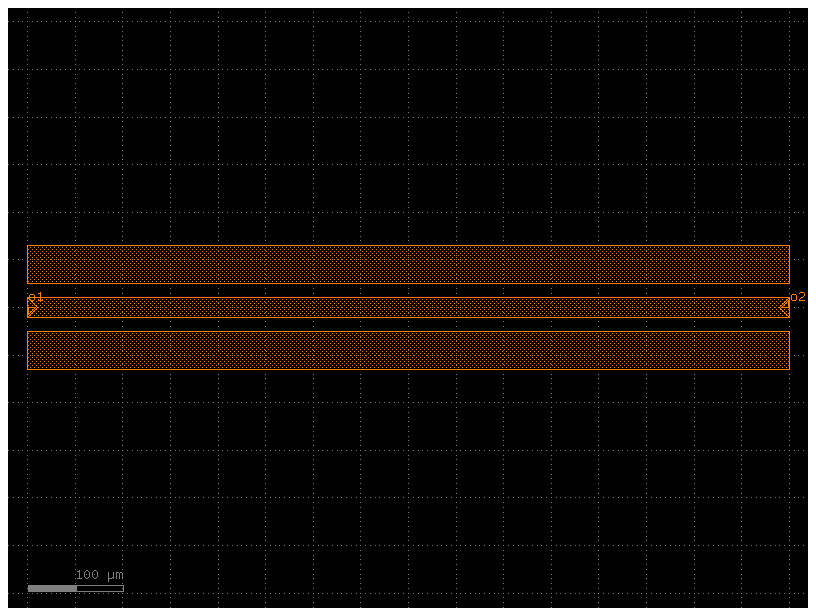

In [15]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes
        gap_width: gap between signal and ground electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    # Top ground electrode
    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))

    # Center signal electrode
    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    # Bottom ground electrode
    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))

    # Add ports at the signal center (one per side)
    # The CPW port API computes the gap element surfaces from s_width and gap_width
    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure simulation with DrivenSim for Lumped Ports

In [ ]:
from gsim.palace import DrivenSim

# Create simulation object
sim_lumped = DrivenSim()

# Set output directory
sim_lumped.set_output_dir("./palace-sim-cpw")

# Set the component geometry
sim_lumped.set_geometry(c)

# Configure layer stack from active PDK
sim_lumped.set_stack(substrate_thickness=2.0, air_above=300.0)

# Configure left CPW port (single port at signal center)
sim_lumped.add_cpw_port("o1", layer="topmetal2", s_width=20, gap_width=15, length=5.0, offset=-2.5, excited=True)

# Configure right CPW port (single port at signal center)
sim_lumped.add_cpw_port("o2", layer="topmetal2", s_width=20, gap_width=15, length=5.0, offset=-2.5, excited=False)

# Configure driven simulation (frequency sweep for S-parameters)
sim_lumped.set_driven(fmin=1e9, fmax=100e9, num_points=40)

# Validate configuration
print(sim_lumped.validate_config())

### Configure simulation with DrivenSim for WavePorts

In [ ]:
# Create simulation object
sim_waveport = DrivenSim()

# Set output directory
sim_waveport.set_output_dir("./palace-sim-cpw-waveport")

# Set the component geometry
sim_waveport.set_geometry(c)

# Configure layer stack from active PDK
sim_waveport.set_stack(substrate_thickness=2.0, air_above=300.0)

# Configure left CPW port (single port at signal center)
sim_waveport.add_wave_port("o1", layer="topmetal2", z_margin=22.0, lateral_margin=20.0, mode=1, excited=True)

# Configure right CPW port (single port at signal center)
sim_waveport.add_wave_port("o2", layer="topmetal2", z_margin=22.0, lateral_margin=20.0, mode=1, excited=False)

# Configure driven simulation (frequency sweep for S-parameters)
sim_waveport.set_driven(fmin=1e9, fmax=100e9, num_points=40)

# Validate configuration
print(sim_waveport.validate_config())

In [ ]:
# Generate mesh with planar conductors (presets: "coarse", "default", "fine")
sim_lumped.mesh(preset="default", planar_conductors=False, margin=0.0)
sim_waveport.mesh(preset="default", planar_conductors=False, margin=0.0)

In [ ]:
# Solid view — coloured surfaces per physical group, boundary transparent
sim_lumped.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

# Solid view — coloured surfaces per physical group, boundary transparent
sim_waveport.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

### Run simulation on cloud

In [ ]:
# Run driven simulation with lumped ports on GDSFactory+ cloud
results_lumped = sim_lumped.run()

In [ ]:
# Run driven simulation with waveports on GDSFactory+ cloud
results_waveport = sim_waveport.run()

In [ ]:
from gsim.palace import load_sparams

sp1 = load_sparams(results_lumped)
sp1.plot()

sp2 = load_sparams(results_waveport)
sp2.plot()